## Notebook Description: Principal Component Analysis of Ruminal Fermentation Parameters

This notebook performs a comprehensive Principal Component Analysis (PCA) on ruminal fermentation parameters to explore the relationships between different feed substrates, functional groups, and research centers. Initially, raw fermentation data is loaded, transformed into a wide format where each parameter is a column, and then aggregated by `substrate_id`. The aggregated dataset, `df3`, undergoes standardization using `StandardScaler` and imputation of missing values. PCA is applied to reduce the dimensionality to two principal components (PC1 and PC2), with biplots generated to visualize the data. Key visualizations include biplots of all data colored by 'functional' group, separate biplots for each 'center' (CIAT, ICARDA, ILRI) colored by 'functional' group, and biplots for each 'functional' group (Legume, Grass) colored by 'center'. The final biplot combines both 'functional' group and 'center' for a multifaceted view, allowing for the interpretation of parameter correlations and sample clustering in the reduced-dimensional space. The explained variance ratio for PC1 ($PC1_{exp\_var}$) and PC2 ($PC2_{exp\_var}$) is presented on the axes.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Data Input

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/lmf/data/03_30_2026_pca_stefan/01_all_parameters_48h_normalized.csv')
df.head(2)

,exp_id,substrate_id,rumen_fluid_vid,center,channel_id,functional,family,genus,species,exclusion,parameter,param_base,unit,value_48
0,AMC 03,1000,37&261,ILRI,202,Legume,Fabaceae,Teramnus,uncinatus,NaN,Acetate [mmol/g],Acetate,mmol/g,3.423954
1,AMC 03,1000,37&261,ILRI,202,Legume,Fabaceae,Teramnus,uncinatus,NaN,Butyrate [mmol/g],Butyrate,mmol/g,0.464059


In [ ]:
# Categories in column 'functional'
df.functional.unique()

array(['Legume', 'Grass', 'Others', nan], dtype=object)

# Sort dataframe with variables in column format

In [ ]:
# 2. create column name with "param_base [unit]"
df['param'] = df['param_base'] + ' [' + df['unit'] + ']'

# 3. Switch to a wide format
df2 = df.pivot_table( index=['exp_id','substrate_id','rumen_fluid_vid','center','channel_id','functional','family','genus','species'], columns='param', values='value_48').reset_index()

# 4. (Opcional) limpiar nombre de columnas
df2.columns.name = None


In [ ]:
df2.head(2)

,exp_id,substrate_id,rumen_fluid_vid,center,channel_id,functional,family,genus,species,Acetate [mmol/g],...,CH4 [mL/mmol],CH4 [ml/L],CH4 [ml/g],Caproate [mmol/g],GP [ml/g],Isobutyrate [mmol/g],Isovalerate [mmol/g],Propionate [mmol/g],SCFA [mmol/g],Valerate [mmol/g]
0,AMC 03,987,37&261,ILRI,212,Legume,Fabaceae,Vicia,villosa,4.752656,...,6.125310,150.402905,43.603856,0.012838,289.913656,0.100930,0.198982,1.106795,7.118637,0.109230
1,AMC 03,987,37&261,ILRI,225,Legume,Fabaceae,Vicia,villosa,4.764719,...,5.567727,143.781703,39.781272,0.011178,276.678265,0.099602,0.197654,1.116423,7.144976,0.108676


# Averaged dataframe

In [ ]:
# Identify descriptive non-numeric columns from df2
descriptive_non_numeric_cols = [
    'exp_id', 'rumen_fluid_vid', 'center', 'channel_id','functional', 'family', 'genus', 'species'
]

# Identify numeric columns (parameters and channel_id)
numeric_cols = df2.select_dtypes(include=np.number).columns.tolist()

# Create an aggregation dictionary
agg_dict = {}

# For descriptive non-numeric columns, take the first value
for col in descriptive_non_numeric_cols:
    if col in df2.columns:
        agg_dict[col] = 'first'

# For numeric columns (excluding 'substrate_id' which is the groupby key), take the mean
for col in numeric_cols:
    if col != 'substrate_id' and col in df2.columns:
        agg_dict[col] = 'mean'

# Perform the aggregation
df3 = df2.groupby('substrate_id').agg(agg_dict).reset_index()

# Reorder columns for better readability: substrate_id first, then descriptive, then numeric parameters
ordered_cols_for_df3 = ['substrate_id'] + descriptive_non_numeric_cols + \
                       [col for col in numeric_cols if col != 'substrate_id']

# Filter to include only columns that exist in df3 after aggregation
ordered_cols_for_df3 = [col for col in ordered_cols_for_df3 if col in df3.columns]

df3 = df3[ordered_cols_for_df3]
df3 = df3.drop("channel_id", axis='columns')

display(df3.head())

,substrate_id,exp_id,rumen_fluid_vid,center,functional,family,genus,species,Acetate [mmol/g],Butyrate [mmol/g],...,CH4 [mL/mmol],CH4 [ml/L],CH4 [ml/g],Caproate [mmol/g],GP [ml/g],Isobutyrate [mmol/g],Isovalerate [mmol/g],Propionate [mmol/g],SCFA [mmol/g],Valerate [mmol/g]
0,987,AMC 03,37&261,ILRI,Legume,Fabaceae,Vicia,villosa,4.863426,0.880086,...,5.368107,147.657077,39.372261,0.013456,264.507407,0.106421,0.205881,1.144575,7.330282,0.116437
1,988,AMC 03,37&261,ILRI,Legume,Fabaceae,Lablab,purpureus,4.641175,0.891695,...,5.273431,138.438992,36.887829,0.013606,265.024048,0.106147,0.208907,1.016438,6.995688,0.117721
2,989,AMC 03,37&261,ILRI,Legume,Fabaceae,Arachis,glabrata,4.917578,0.732516,...,5.730142,147.755120,41.372027,0.007564,279.681090,0.099447,0.191755,1.155866,7.220996,0.116270
3,990,AMC 03,37&261,ILRI,Legume,Fabaceae,Medicago,sativa,4.663053,0.654356,...,5.902119,150.471225,41.124374,0.009962,272.575328,0.117121,0.225949,1.168460,6.965328,0.126429
4,991,AMC 03,37&261,ILRI,Legume,Fabaceae,Macroptilium,lathyroides,4.800081,0.908594,...,5.708018,150.744558,41.035469,0.012092,272.228404,0.105521,0.208656,1.020317,7.191371,0.136111


In [ ]:
# Save data frame
#df3.to_csv('/content/drive/MyDrive/lmf/output/03_30_2026_pca_stefan/data_frame_for_pca.csv', index = None)

# PCA Biplot with all data

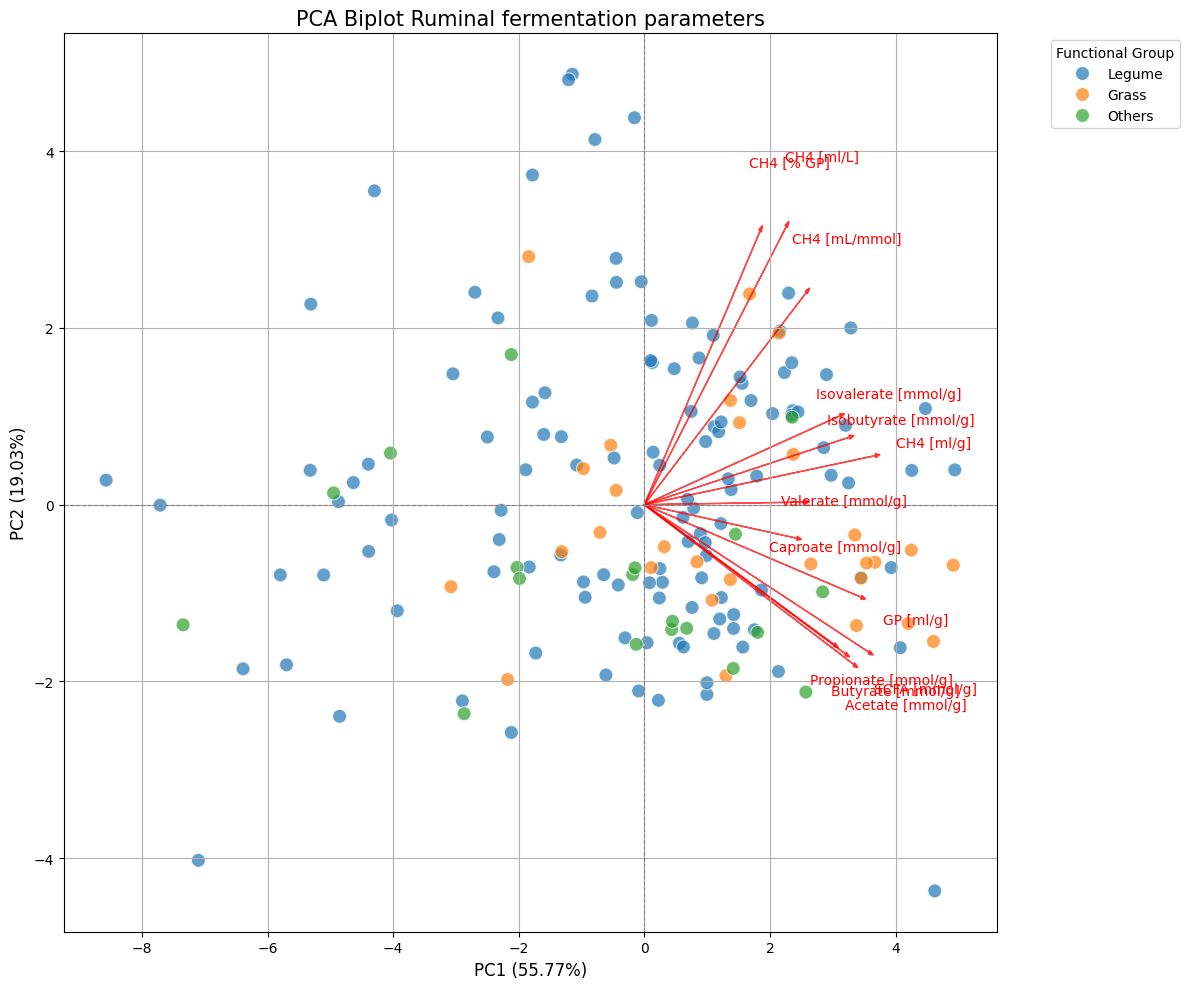

In [ ]:
df = df3.copy()

# Identificar columnas numéricas para PCA (excluyendo 'substrate_id' y otras columnas descriptivas)
# Primero, obtén todas las columnas numéricas de df
numeric_cols_df = df.select_dtypes(include=np.number).columns.tolist()

# Excluir 'substrate_id' ya que es un identificador, no una variable para PCA
pca_features = [col for col in numeric_cols_df if col != 'substrate_id']

X = df[pca_features].copy()

# Reemplazar valores infinitos o muy grandes con NaN, y luego imputar o manejar
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True) # Imputar NaNs con la media de la columna

# Escalar los datos antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2) # Reducir a 2 componentes principales para visualización 2D
principal_components = pca.fit_transform(X_scaled)

# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Concatenar con las columnas descriptivas de df para visualización
final_df = pd.concat([df[['functional']], pca_df], axis=1)

# Crear el biplot
plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', data=final_df, hue='functional', s=100, alpha=0.7 )

# Añadir etiquetas de los puntos (opcional, puede ser muy denso)
# for i, row in final_df.iterrows():
#     plt.text(row['PC1'] + 0.1, row['PC2'] + 0.1, row['substrate_id'], fontsize=8)

# Añadir los vectores de correlación (loadings)
# Obtener los loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, feature in enumerate(pca_features):
    plt.arrow(0, 0, loadings[i, 0]*4, loadings[i, 1]*4, color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0] * 5, loadings[i, 1] * 5, feature, color='r', ha='center', va='center', fontsize=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('PCA Biplot Ruminal fermentation parameters', fontsize=15)
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(title='Functional Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/lmf/output/03_30_2026_pca_stefan/plots/pca_all.png", dpi=300, bbox_inches='tight')
plt.show()


# Biplots by Center

## CIAT

In [ ]:
ciat = df3[df3['center'] == 'CIAT']
ciat = ciat.reset_index(drop=True)
ciat.head(2)

,substrate_id,exp_id,rumen_fluid_vid,center,functional,family,genus,species,Acetate [mmol/g],Butyrate [mmol/g],...,CH4 [mL/mmol],CH4 [ml/L],CH4 [ml/g],Caproate [mmol/g],GP [ml/g],Isobutyrate [mmol/g],Isovalerate [mmol/g],Propionate [mmol/g],SCFA [mmol/g],Valerate [mmol/g]
0,1044,AMC 08,22&261,CIAT,Legume,Fabaceae,Aeschynomene,brasiliana,3.693475,0.586251,...,5.889744,171.306756,32.731050,0.005163,192.064492,0.092706,0.167665,0.949567,5.586766,0.091940
1,1045,AMC 08,22&261,CIAT,Legume,Fabaceae,Albizzia,saman,1.609156,0.166678,...,2.663703,127.989657,7.333193,0.001242,57.658881,0.020751,0.062383,1.015961,2.898933,0.022761


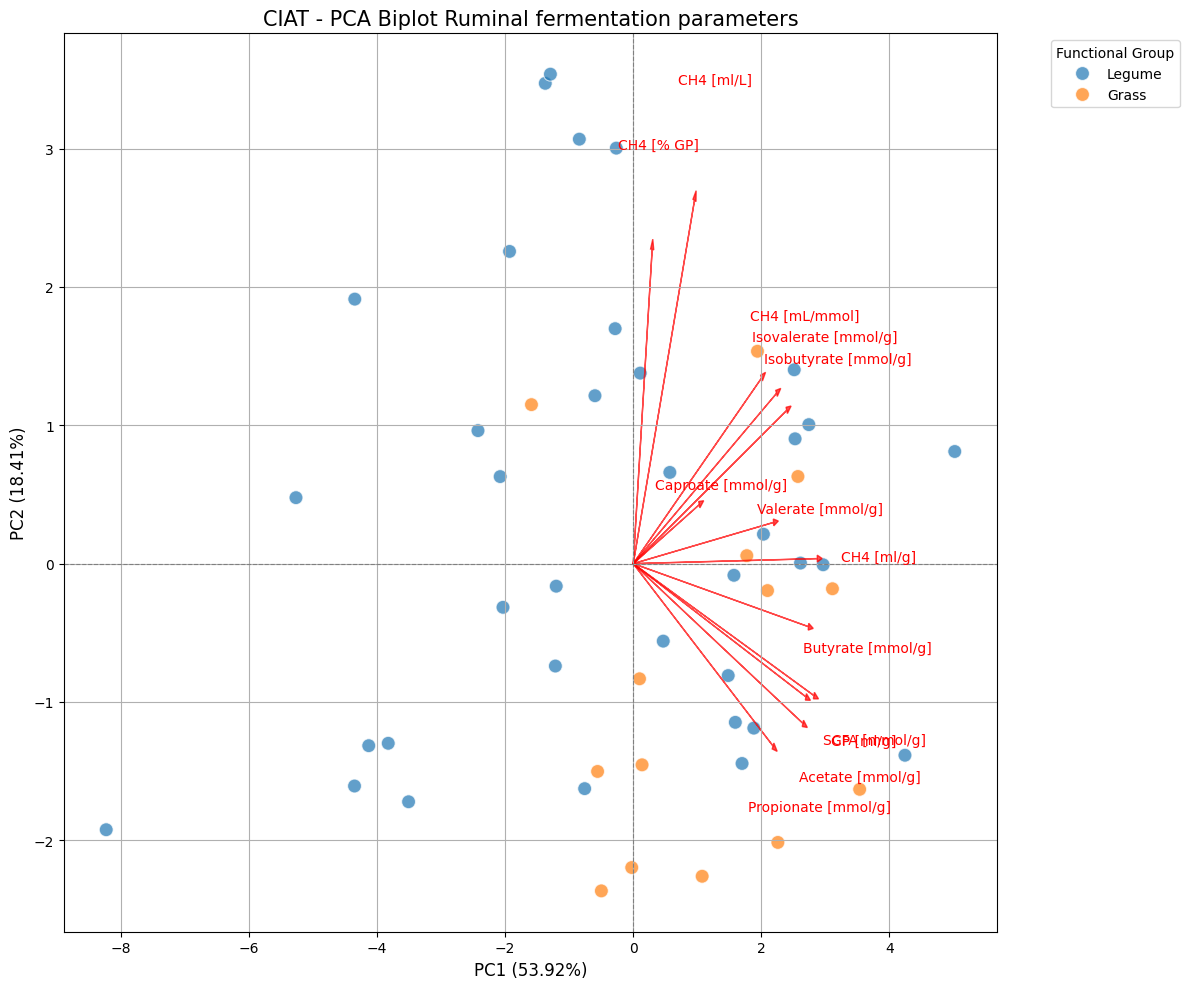

In [ ]:
df = ciat.copy()

# Identificar columnas numéricas para PCA (excluyendo 'substrate_id' y otras columnas descriptivas)
# Primero, obtén todas las columnas numéricas de df
numeric_cols_df = df.select_dtypes(include=np.number).columns.tolist()

# Excluir 'substrate_id' ya que es un identificador, no una variable para PCA
pca_features = [col for col in numeric_cols_df if col != 'substrate_id']

X = df[pca_features].copy()

# Reemplazar valores infinitos o muy grandes con NaN, y luego imputar o manejar
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True) # Imputar NaNs con la media de la columna

# Escalar los datos antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2) # Reducir a 2 componentes principales para visualización 2D
principal_components = pca.fit_transform(X_scaled)

# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Concatenar con las columnas descriptivas de df para visualización
final_df = pd.concat([df[['functional']], pca_df], axis=1)

# Crear el biplot
plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', data=final_df, hue='functional', s=100, alpha=0.7 )

# Añadir etiquetas de los puntos (opcional, puede ser muy denso)
# for i, row in final_df.iterrows():
#     plt.text(row['PC1'] + 0.1, row['PC2'] + 0.1, row['substrate_id'], fontsize=8)

# Añadir los vectores de correlación (loadings)
# Obtener los loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, feature in enumerate(pca_features):
    plt.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3, color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0] * 4, loadings[i, 1] * 4, feature, color='r', ha='center', va='center', fontsize=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('CIAT - PCA Biplot Ruminal fermentation parameters', fontsize=15)
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(title='Functional Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/lmf/output/03_30_2026_pca_stefan/plots/pca_ciat.png", dpi=300, bbox_inches='tight')
plt.show()


## ICARDA

In [ ]:
icarda = df3[df3['center'] == 'ICARDA']
icarda = icarda.reset_index(drop=True)
icarda.head(2)

,substrate_id,exp_id,rumen_fluid_vid,center,functional,family,genus,species,Acetate [mmol/g],Butyrate [mmol/g],...,CH4 [mL/mmol],CH4 [ml/L],CH4 [ml/g],Caproate [mmol/g],GP [ml/g],Isobutyrate [mmol/g],Isovalerate [mmol/g],Propionate [mmol/g],SCFA [mmol/g],Valerate [mmol/g]
0,1137,AMC 14,22&49,ICARDA,Legume,Fabaceae,Medicago,sativa subsp. sativa,4.713107,0.627638,...,6.539079,170.551271,46.363781,0.008003,272.614312,0.124548,0.232188,1.241951,7.087435,0.140000
1,1138,AMC 14,22&49,ICARDA,Legume,Fabaceae,Medicago,sativa,4.312470,0.590653,...,7.760431,191.337642,48.884187,0.007799,255.021092,0.094976,0.180897,1.003282,6.291752,0.101675


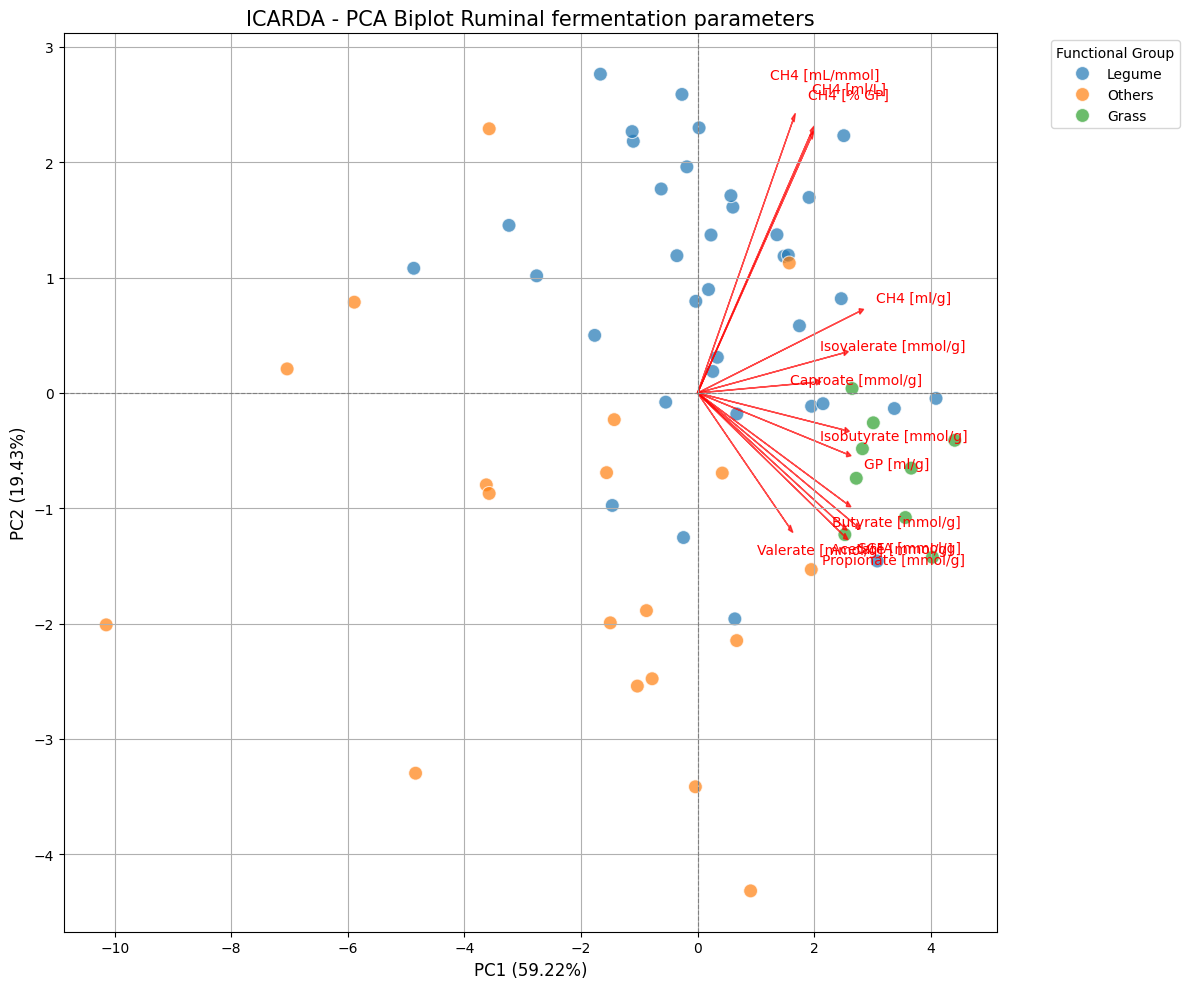

In [ ]:
df = icarda.copy()

# Identificar columnas numéricas para PCA (excluyendo 'substrate_id' y otras columnas descriptivas)
# Primero, obtén todas las columnas numéricas de df
numeric_cols_df = df.select_dtypes(include=np.number).columns.tolist()

# Excluir 'substrate_id' ya que es un identificador, no una variable para PCA
pca_features = [col for col in numeric_cols_df if col != 'substrate_id']

X = df[pca_features].copy()

# Reemplazar valores infinitos o muy grandes con NaN, y luego imputar o manejar
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True) # Imputar NaNs con la media de la columna

# Escalar los datos antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2) # Reducir a 2 componentes principales para visualización 2D
principal_components = pca.fit_transform(X_scaled)

# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Concatenar con las columnas descriptivas de df para visualización
final_df = pd.concat([df[['functional']], pca_df], axis=1)

# Crear el biplot
plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', data=final_df, hue='functional', s=100, alpha=0.7 )

# Añadir etiquetas de los puntos (opcional, puede ser muy denso)
# for i, row in final_df.iterrows():
#     plt.text(row['PC1'] + 0.1, row['PC2'] + 0.1, row['substrate_id'], fontsize=8)

# Añadir los vectores de correlación (loadings)
# Obtener los loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, feature in enumerate(pca_features):
    plt.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3, color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0] * 4, loadings[i, 1] * 3.5, feature, color='r', ha='center', va='center', fontsize=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('ICARDA - PCA Biplot Ruminal fermentation parameters', fontsize=15)
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(title='Functional Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/lmf/output/03_30_2026_pca_stefan/plots/pca_icarda.png", dpi=300, bbox_inches='tight')
plt.show()


## ILRI

In [ ]:
ilri = df3[df3['center'] == 'ILRI']
ilri = ilri.reset_index(drop=True)
ilri.head(2)

,substrate_id,exp_id,rumen_fluid_vid,center,functional,family,genus,species,Acetate [mmol/g],Butyrate [mmol/g],...,CH4 [mL/mmol],CH4 [ml/L],CH4 [ml/g],Caproate [mmol/g],GP [ml/g],Isobutyrate [mmol/g],Isovalerate [mmol/g],Propionate [mmol/g],SCFA [mmol/g],Valerate [mmol/g]
0,987,AMC 03,37&261,ILRI,Legume,Fabaceae,Vicia,villosa,4.863426,0.880086,...,5.368107,147.657077,39.372261,0.013456,264.507407,0.106421,0.205881,1.144575,7.330282,0.116437
1,988,AMC 03,37&261,ILRI,Legume,Fabaceae,Lablab,purpureus,4.641175,0.891695,...,5.273431,138.438992,36.887829,0.013606,265.024048,0.106147,0.208907,1.016438,6.995688,0.117721


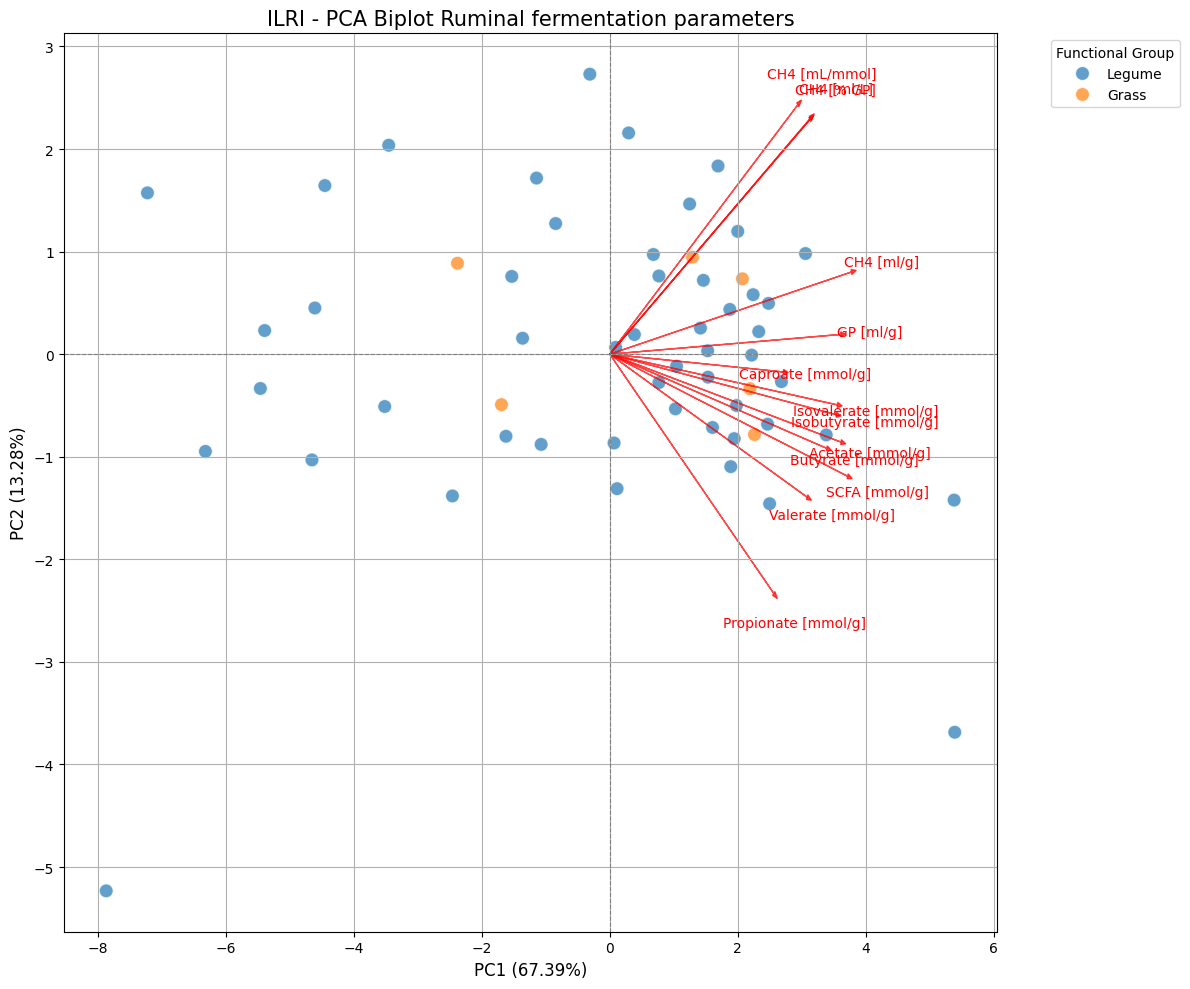

In [ ]:
df = ilri.copy()

# Identificar columnas numéricas para PCA (excluyendo 'substrate_id' y otras columnas descriptivas)
# Primero, obtén todas las columnas numéricas de df
numeric_cols_df = df.select_dtypes(include=np.number).columns.tolist()

# Excluir 'substrate_id' ya que es un identificador, no una variable para PCA
pca_features = [col for col in numeric_cols_df if col != 'substrate_id']

X = df[pca_features].copy()

# Reemplazar valores infinitos o muy grandes con NaN, y luego imputar o manejar
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True) # Imputar NaNs con la media de la columna

# Escalar los datos antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2) # Reducir a 2 componentes principales para visualización 2D
principal_components = pca.fit_transform(X_scaled)

# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Concatenar con las columnas descriptivas de df para visualización
final_df = pd.concat([df[['functional']], pca_df], axis=1)

# Crear el biplot
plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', data=final_df, hue='functional', s=100, alpha=0.7 )

# Añadir etiquetas de los puntos (opcional, puede ser muy denso)
# for i, row in final_df.iterrows():
#     plt.text(row['PC1'] + 0.1, row['PC2'] + 0.1, row['substrate_id'], fontsize=8)

# Añadir los vectores de correlación (loadings)
# Obtener los loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, feature in enumerate(pca_features):
    plt.arrow(0, 0, loadings[i, 0]*4, loadings[i, 1]*4, color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0] * 4.5, loadings[i, 1] * 4.5, feature, color='r', ha='center', va='center', fontsize=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('ILRI - PCA Biplot Ruminal fermentation parameters', fontsize=15)
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(title='Functional Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/lmf/output/03_30_2026_pca_stefan/plots/pca_ilri.png", dpi=300, bbox_inches='tight')
plt.show()


# Biplots by Functional group

## Legume

In [ ]:
legume = df3[df3['functional'] == 'Legume']
legume = legume.reset_index(drop=True)
legume.head(2)

,substrate_id,exp_id,rumen_fluid_vid,center,functional,family,genus,species,Acetate [mmol/g],Butyrate [mmol/g],...,CH4 [mL/mmol],CH4 [ml/L],CH4 [ml/g],Caproate [mmol/g],GP [ml/g],Isobutyrate [mmol/g],Isovalerate [mmol/g],Propionate [mmol/g],SCFA [mmol/g],Valerate [mmol/g]
0,987,AMC 03,37&261,ILRI,Legume,Fabaceae,Vicia,villosa,4.863426,0.880086,...,5.368107,147.657077,39.372261,0.013456,264.507407,0.106421,0.205881,1.144575,7.330282,0.116437
1,988,AMC 03,37&261,ILRI,Legume,Fabaceae,Lablab,purpureus,4.641175,0.891695,...,5.273431,138.438992,36.887829,0.013606,265.024048,0.106147,0.208907,1.016438,6.995688,0.117721


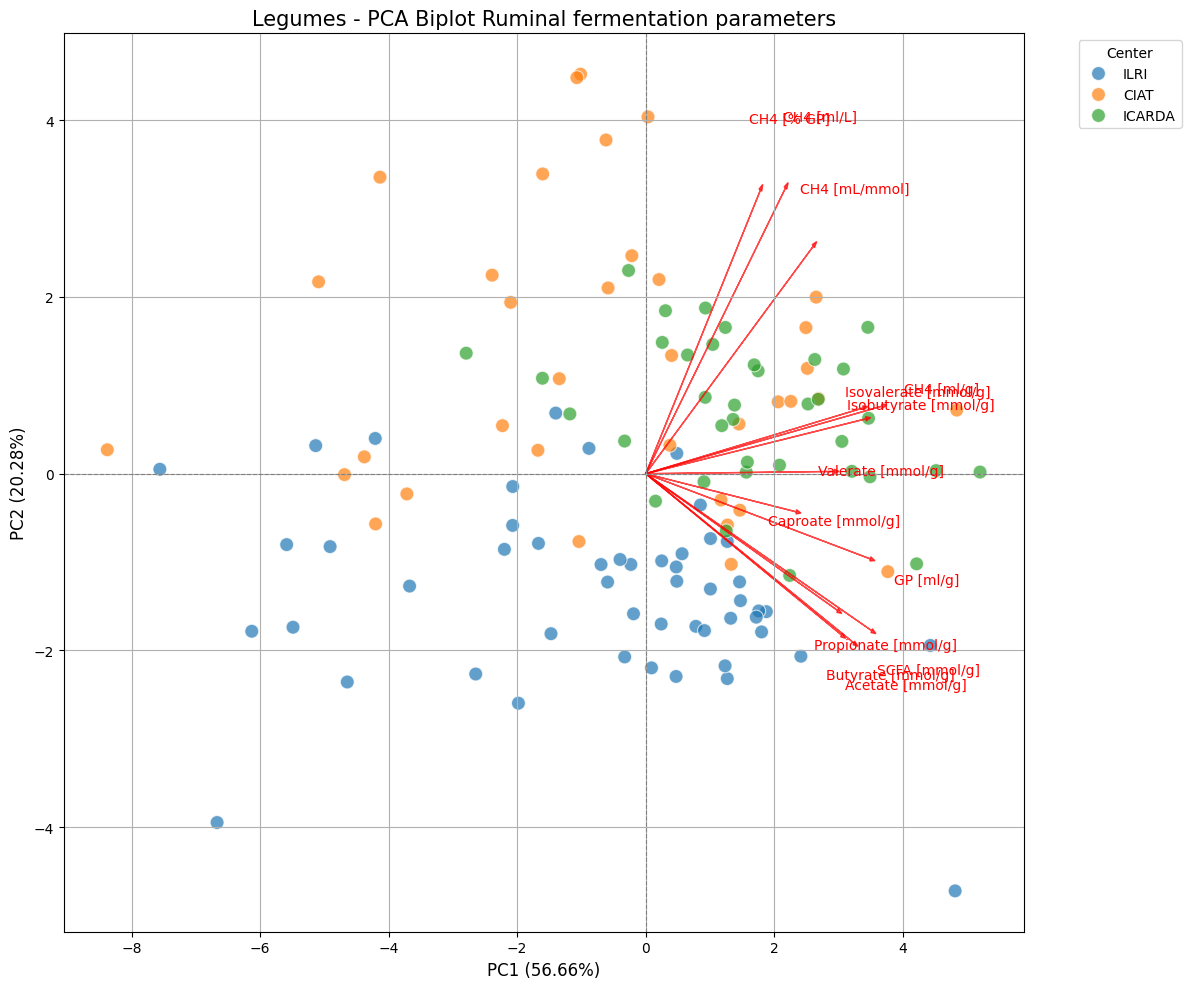

In [ ]:
df = legume.copy()

# Identificar columnas numéricas para PCA (excluyendo 'substrate_id' y otras columnas descriptivas)
# Primero, obtén todas las columnas numéricas de df
numeric_cols_df = df.select_dtypes(include=np.number).columns.tolist()

# Excluir 'substrate_id' ya que es un identificador, no una variable para PCA
pca_features = [col for col in numeric_cols_df if col != 'substrate_id']

X = df[pca_features].copy()

# Reemplazar valores infinitos o muy grandes con NaN, y luego imputar o manejar
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True) # Imputar NaNs con la media de la columna

# Escalar los datos antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2) # Reducir a 2 componentes principales para visualización 2D
principal_components = pca.fit_transform(X_scaled)

# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Concatenar con las columnas descriptivas de df para visualización
final_df = pd.concat([df[['center']], pca_df], axis=1)

# Crear el biplot
plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', data=final_df, hue='center', s=100, alpha=0.7 )

# Añadir etiquetas de los puntos (opcional, puede ser muy denso)
# for i, row in final_df.iterrows():
#     plt.text(row['PC1'] + 0.1, row['PC2'] + 0.1, row['substrate_id'], fontsize=8)

# Añadir los vectores de correlación (loadings)
# Obtener los loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, feature in enumerate(pca_features):
    plt.arrow(0, 0, loadings[i, 0]*4, loadings[i, 1]*4, color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0] * 5, loadings[i, 1] * 5, feature, color='r', ha='center', va='center', fontsize=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('Legumes - PCA Biplot Ruminal fermentation parameters', fontsize=15)
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(title='Center', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/lmf/output/03_30_2026_pca_stefan/plots/pca_legumes.png", dpi=300, bbox_inches='tight')
plt.show()


## Grass

In [ ]:
grass = df3[df3['functional'] == 'Grass']
grass = grass.reset_index(drop=True)
grass.head(2)

,substrate_id,exp_id,rumen_fluid_vid,center,functional,family,genus,species,Acetate [mmol/g],Butyrate [mmol/g],...,CH4 [mL/mmol],CH4 [ml/L],CH4 [ml/g],Caproate [mmol/g],GP [ml/g],Isobutyrate [mmol/g],Isovalerate [mmol/g],Propionate [mmol/g],SCFA [mmol/g],Valerate [mmol/g]
0,1038,AMC 05,49&179,ILRI,Grass,Poaceae,Chloris,gayana,4.930402,0.597473,...,5.544645,147.818929,39.865620,0.004701,269.711305,0.123537,0.212396,1.344332,7.35344,0.140599
1,1039,AMC 05,49&179,ILRI,Grass,Poaceae,Cenchrus,Purpureues,4.600614,0.713988,...,5.619453,153.960968,37.955093,0.009086,246.968182,0.098115,0.176964,1.155703,6.85411,0.099640


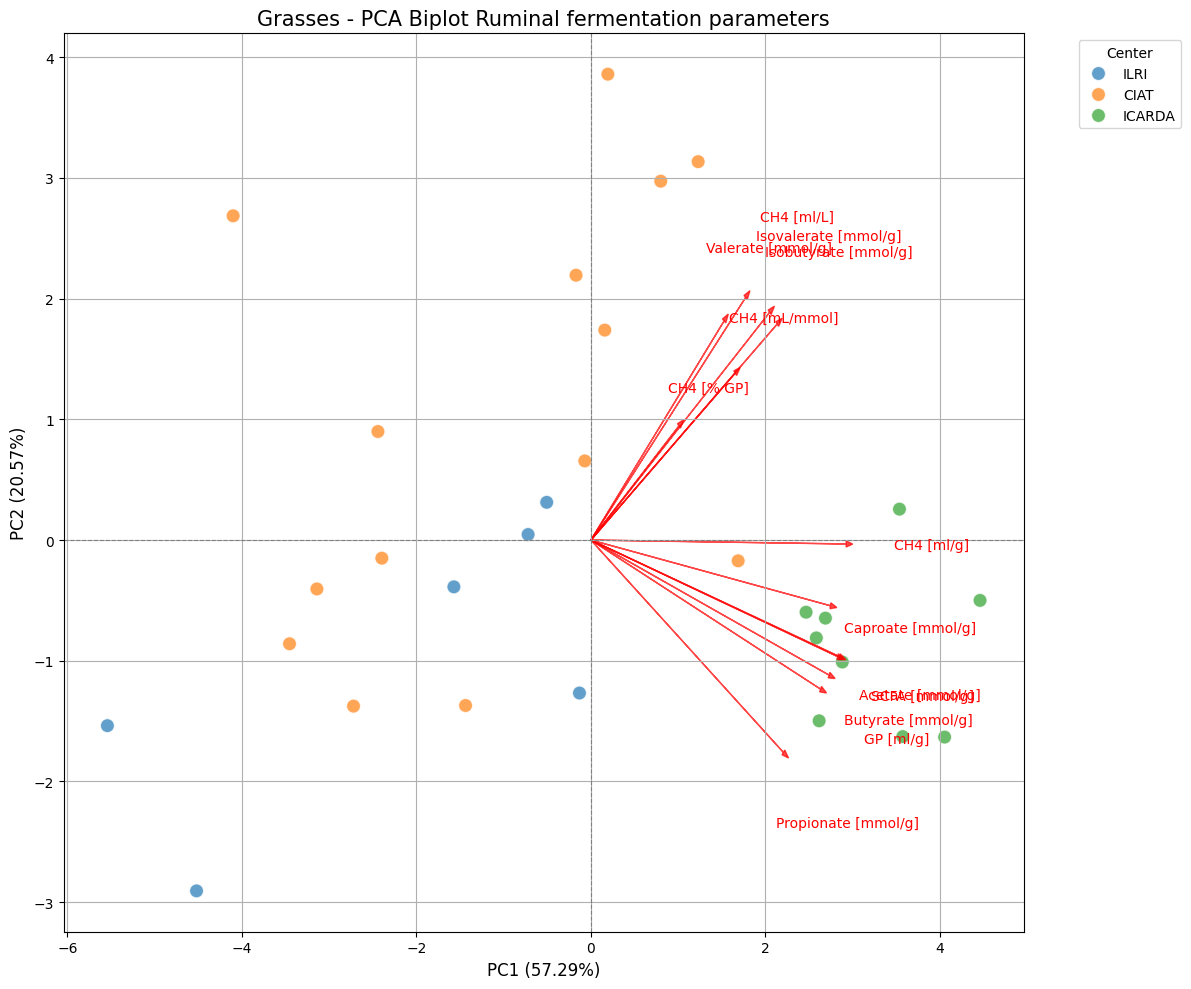

In [ ]:
df = grass.copy()

# Identificar columnas numéricas para PCA (excluyendo 'substrate_id' y otras columnas descriptivas)
# Primero, obtén todas las columnas numéricas de df
numeric_cols_df = df.select_dtypes(include=np.number).columns.tolist()

# Excluir 'substrate_id' ya que es un identificador, no una variable para PCA
pca_features = [col for col in numeric_cols_df if col != 'substrate_id']

X = df[pca_features].copy()

# Reemplazar valores infinitos o muy grandes con NaN, y luego imputar o manejar
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True) # Imputar NaNs con la media de la columna

# Escalar los datos antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2) # Reducir a 2 componentes principales para visualización 2D
principal_components = pca.fit_transform(X_scaled)

# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Concatenar con las columnas descriptivas de df para visualización
final_df = pd.concat([df[['center']], pca_df], axis=1)

# Crear el biplot
plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', data=final_df, hue='center', s=100, alpha=0.7 )

# Añadir etiquetas de los puntos (opcional, puede ser muy denso)
# for i, row in final_df.iterrows():
#     plt.text(row['PC1'] + 0.1, row['PC2'] + 0.1, row['substrate_id'], fontsize=8)

# Añadir los vectores de correlación (loadings)
# Obtener los loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, feature in enumerate(pca_features):
    plt.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3, color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0] * 4, loadings[i, 1] * 4, feature, color='r', ha='center', va='center', fontsize=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('Grasses - PCA Biplot Ruminal fermentation parameters', fontsize=15)
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(title='Center', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/lmf/output/03_30_2026_pca_stefan/plots/pca_grasses.png", dpi=300, bbox_inches='tight')
plt.show()


## Biplot by centers and functional group

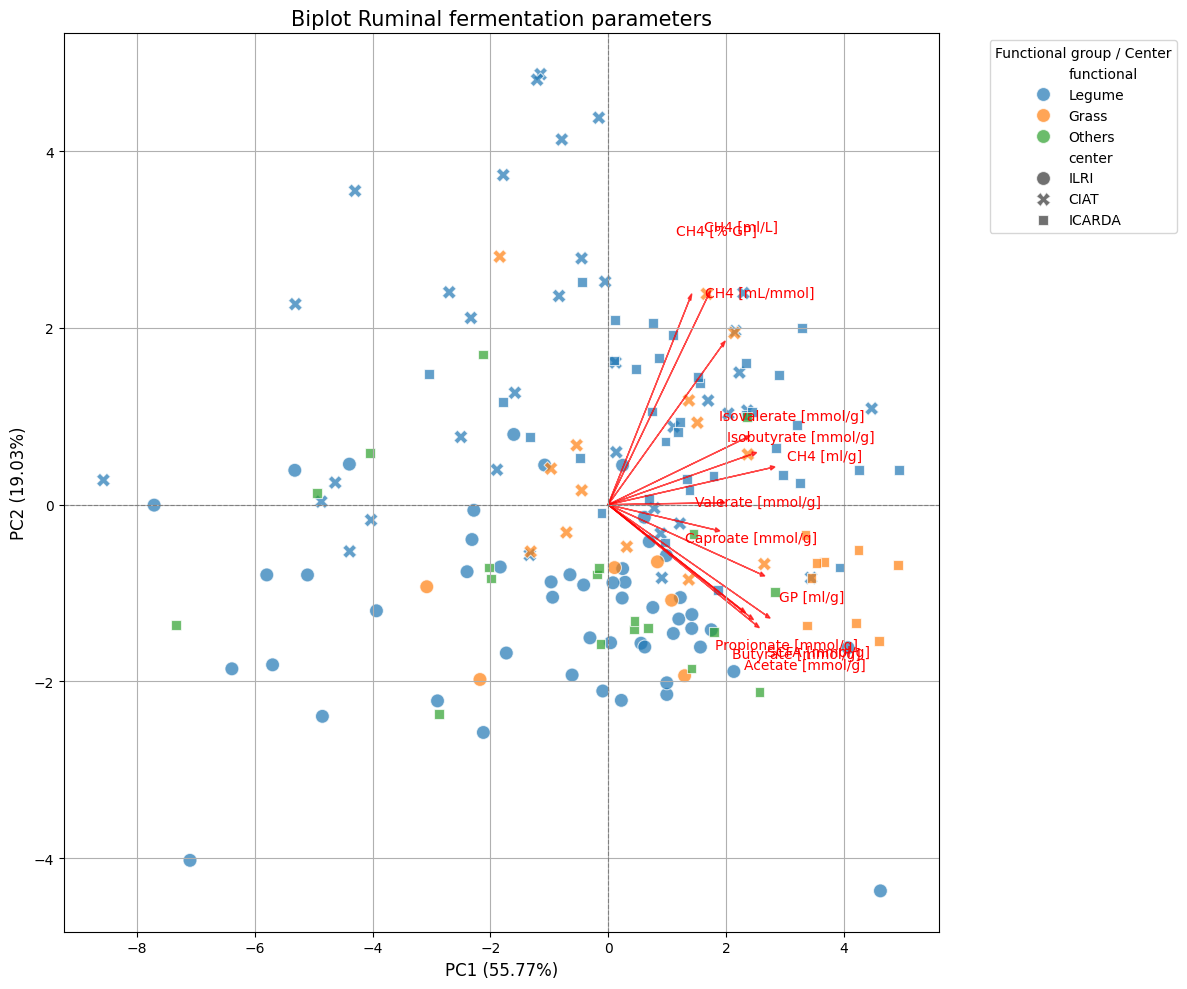

In [ ]:
df = df3.copy()

# Identificar columnas numéricas para PCA (excluyendo 'substrate_id' y otras columnas descriptivas)
# Primero, obtén todas las columnas numéricas de df
numeric_cols_df = df.select_dtypes(include=np.number).columns.tolist()

# Excluir 'substrate_id' ya que es un identificador, no una variable para PCA
pca_features = [col for col in numeric_cols_df if col != 'substrate_id']

X = df[pca_features].copy()

# Reemplazar valores infinitos o muy grandes con NaN, y luego imputar o manejar
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True) # Imputar NaNs con la media de la columna

# Escalar los datos antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2) # Reducir a 2 componentes principales para visualización 2D
principal_components = pca.fit_transform(X_scaled)

# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Concatenar con las columnas descriptivas de df para visualización, incluyendo 'functional' y 'center'
final_df = pd.concat([df[['functional', 'center']], pca_df], axis=1)

# Crear el biplot
plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', data=final_df, hue='functional', style='center', s=100, alpha=0.7 )

# Añadir etiquetas de los puntos (opcional, puede ser muy denso)
# for i, row in final_df.iterrows():
#     plt.text(row['PC1'] + 0.1, row['PC2'] + 0.1, row['substrate_id'], fontsize=8)

# Añadir los vectores de correlación (loadings)
# Obtener los loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, feature in enumerate(pca_features):
    plt.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3, color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0] * 4, loadings[i, 1] * 4, feature, color='r', ha='center', va='center', fontsize=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('Biplot Ruminal fermentation parameters', fontsize=15)
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(title='Functional group / Center', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/lmf/output/03_30_2026_pca_stefan/plots/pca_functional_and_centers.png", dpi=300, bbox_inches='tight')
plt.show()